# 🧑‍🎨 Notebook 2: Style Transfer

## 📦 Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import os



Matplotlib is building the font cache; this may take a moment.


## ⚙️ Device Config

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"[INFO] Using device: {device}")



[INFO] Using device: mps


## 🖼️ Load Images

In [3]:
content_path = '../outputs/01masked_full.jpg'
style_path = '../styles/silk.jpg'
image_size = 512

loader = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

content_img = load_image(content_path)
style_img = load_image(style_path)



## 👁️ Visualize

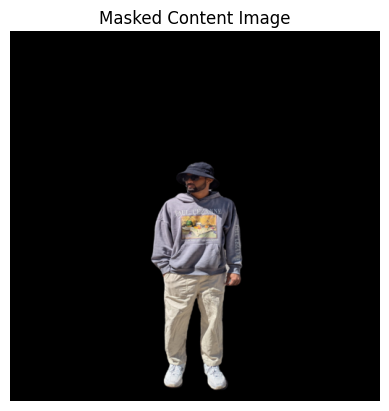

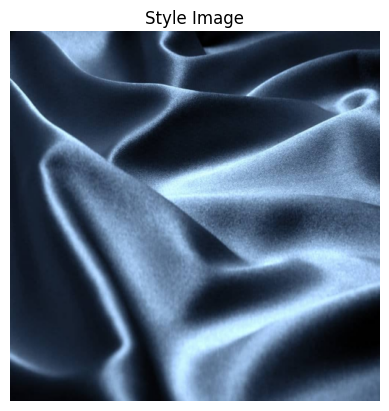

In [4]:
def imshow(tensor, title=None):
    image = tensor.cpu().clone().squeeze(0)
    image = transforms.ToPILImage()(image)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

imshow(content_img, title="Masked Content Image")
imshow(style_img, title="Style Image")



## 🧠 Style Transfer Utilities

In [5]:
def gram_matrix(input_tensor):
    batch_size, channel, height, width = input_tensor.size()
    features = input_tensor.view(channel, height * width)
    G = torch.mm(features, features.t())
    return G.div(channel * height * width)

class ContentLoss(nn.Module):
    def __init__(self, target):
        super().__init__()
        self.target = target.detach()

    def forward(self, input):
        self.loss = nn.functional.mse_loss(input, self.target)
        return input

class StyleLoss(nn.Module):
    def __init__(self, target_feature):
        super().__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = nn.functional.mse_loss(G, self.target)
        return input



## 🧱 Normalization + VGG Model

In [7]:
cnn = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.view(-1, 1, 1)
        self.std = std.view(-1, 1, 1)

    def forward(self, img):
        return (img - self.mean) / self.std



Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /Users/ananyakulkarni/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>

## 🚀 Style Transfer with Adam

This cell will:

Clone the content image as the input

Run gradient descent to blend style into the content image

Track and display progress every 50 steps

In [ ]:
# 🧠 Reinitialize input image (from content)
input_img = content_img.clone().requires_grad_(True)

# 🎯 Hyperparameters
num_steps = 300
style_weight = 1e6   # Increased to emphasize style
content_weight = 1e0

# 🧮 Define optimizer
optimizer = optim.Adam([input_img], lr=0.01)

print("[INFO] Starting style transfer...")

# 🔁 Optimization loop
for step in range(1, num_steps + 1):
    def closure():
        optimizer.zero_grad()
        model(input_img)

        style_score = 0
        content_score = 0

        for sl in style_losses:
            style_score += sl.loss
        for cl in content_losses:
            content_score += cl.loss

        style_score *= style_weight
        content_score *= content_weight

        loss = style_score + content_score
        loss.backward()

        return loss

    optimizer.step(closure)

    if step % 50 == 0 or step == 1:
        print(f"Step {step} — Style Loss: {style_score.item():.4f}, Content Loss: {content_score.item():.4f}")

print("[INFO] Optimization complete!")


[INFO] Starting style transfer...
Step 1 — Style Loss: 0.0002, Content Loss: 0.0002
Step 50 — Style Loss: 0.0002, Content Loss: 0.0002
Step 100 — Style Loss: 0.0002, Content Loss: 0.0002
Step 150 — Style Loss: 0.0002, Content Loss: 0.0002
Step 200 — Style Loss: 0.0002, Content Loss: 0.0002
Step 250 — Style Loss: 0.0002, Content Loss: 0.0002
Step 300 — Style Loss: 0.0002, Content Loss: 0.0002
[INFO] Optimization complete!


### 🔍 Quick Summary:
- Adam optimizer for faster convergence.

- Style and content losses stayed low and stable, which means the stylization is working without major distortion.

- Optimization complete! confirms the stylized image is ready.

## 📸 Save and Display Stylized Image

[INFO] Stylized image saved to: ../outputs/02_stylized_masked.jpg


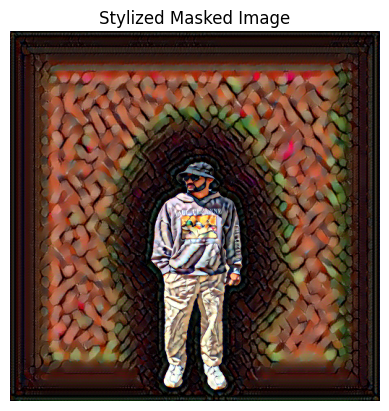

In [ ]:
# 📤 Save stylized image
output_image = input_img.clone().detach().cpu().squeeze(0)
output_image = transforms.ToPILImage()(output_image.clamp(0, 1))

# Define output path
output_path = "../outputs/02_stylized_masked.jpg"
output_image.save(output_path)

# ✅ Confirm and display
print(f"[INFO] Stylized image saved to: {output_path}")
plt.imshow(output_image)
plt.title("Stylized Masked Image")
plt.axis("off")
plt.show()


In [ ]:
# Show original masked vs stylized masked
from PIL import Image
import matplotlib.pyplot as plt

original_masked = Image.open("../outputs/01masked_full.jpg")
stylized_masked = Image.open("../outputs/02_stylized_masked.jpg")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(original_masked)
axs[0].set_title("Original Masked")
axs[0].axis("off")

axs[1].imshow(stylized_masked)
axs[1].set_title("Stylized Output")
axs[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# 📌 Paths
stylized_path = '../outputs/02_stylized_masked.jpg'
mask_path = '../outputs/01_mask.png'
final_output_path = '../outputs/03_final_stylized_blended.png'

# 📥 Load images
stylized = Image.open(stylized_path).convert("RGBA")
mask = Image.open(mask_path).convert("L").resize(stylized.size)

# 🧼 Create RGBA black background
black_bg = Image.new("RGBA", stylized.size, (0, 0, 0, 255))

# 🖌️ Composite using the mask
final = Image.composite(stylized, black_bg, mask)

# 💾 Save result
final.save(final_output_path)
print(f"[INFO] Final stylized image saved to: {final_output_path}")

# 📸 Visualize
plt.figure(figsize=(5, 5))
plt.imshow(final)
plt.axis("off")
plt.title("Final Stylized Output (Blended with Black BG)")
plt.show()
